# QTableBot Showdown: SmeshBot-trained vs Round-Robin-trained

Two checkpoints of the same `agents.qtable_bot.QTableBot` architecture, trained on
different opponent distributions:

- **smesh-trained** (`agents/checkpoints/qtable_bot.json`, from `qtable_vs_smesh.ipynb`)
  — 2000 matches purely against `SmeshBot`.
- **roundrobin-trained** (`agents/checkpoints/qtable_bot_roundrobin.json`, from
  `qtable_vs_roundrobin.ipynb`) — 2000 matches round-robin against
  `RandomBot -> ChaserBot -> SmeshBot`.

Run `qtable_vs_roundrobin.ipynb` first if the second checkpoint doesn't exist yet.

This notebook loads both checkpoints **frozen** (`epsilon=0.0, alpha=0.0` — no further
learning) and plays them against each other for 200 headless matches, alternating
which one is P0/P1 each match to cancel out any positional asymmetry, then compares
win rate, damage dealt/taken, and match length.


In [6]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from smeshlite.core.match import Match, MatchConfig
from agents.qtable_bot import QTableBot


In [7]:
bot_smesh = QTableBot(q_table_path="agents/checkpoints/qtable_bot.json", epsilon=0.0, alpha=0.0)
bot_rr = QTableBot(q_table_path="agents/checkpoints/qtable_bot_roundrobin.json", epsilon=0.0, alpha=0.0)

print(f"smesh-trained      q_table_size={bot_smesh.q_table_size}")
print(f"roundrobin-trained q_table_size={bot_rr.q_table_size}")


smesh-trained      q_table_size=348
roundrobin-trained q_table_size=357


## Matchup loop

Each match: alternate which bot plays P0 vs P1 (even matches: smesh-trained is P0;
odd matches: roundrobin-trained is P0), play a fresh `Match(MatchConfig())` to
completion, then record the winner, match length, and each side's final
damage/stocks from the smesh-trained bot's perspective. `epsilon=0.0` makes both
bots fully greedy (deterministic given the q-tables), so the only randomness left is
tie-breaking between equally-good actions and the starting positions/facings.


In [8]:
N_MATCHES = 200

history = []
t0 = time.time()

for match_idx in range(1, N_MATCHES + 1):
    if match_idx % 2 == 1:
        p0, p1 = bot_smesh, bot_rr
        smesh_idx, rr_idx = 0, 1
    else:
        p0, p1 = bot_rr, bot_smesh
        smesh_idx, rr_idx = 1, 0

    m = Match(MatchConfig())
    m.reset(n_players=2)
    m.set_player_brain(0, p0)
    m.set_player_brain(1, p1)
    bot_smesh.new_episode()
    bot_rr.new_episode()

    while not m.done:
        m.tick()

    if m.winner is None:
        winner_name = "draw"
    elif m.winner == smesh_idx:
        winner_name = "smesh-trained"
    else:
        winner_name = "roundrobin-trained"

    history.append({
        "match": match_idx,
        "smesh_position": "P0" if smesh_idx == 0 else "P1",
        "winner": winner_name,
        "frames": m.frame,
        "smesh_damage_taken": m.characters[smesh_idx].damage_pct,
        "smesh_damage_dealt": m.characters[rr_idx].damage_pct,
        "smesh_stocks_left": m.characters[smesh_idx].stocks,
        "rr_stocks_left": m.characters[rr_idx].stocks,
    })

print(f"done in {time.time() - t0:.1f}s")
df = pd.DataFrame(history)
df.tail()


done in 22.6s


,match,smesh_position,winner,frames,smesh_damage_taken,smesh_damage_dealt,smesh_stocks_left,rr_stocks_left
195,196,P1,roundrobin-trained,953,52.0,0.0,0,2
196,197,P0,roundrobin-trained,1210,59.0,14.0,0,1
197,198,P1,roundrobin-trained,7200,141.0,84.0,1,1
198,199,P0,roundrobin-trained,1210,59.0,14.0,0,1
199,200,P1,roundrobin-trained,1321,106.0,7.0,0,2


## Results


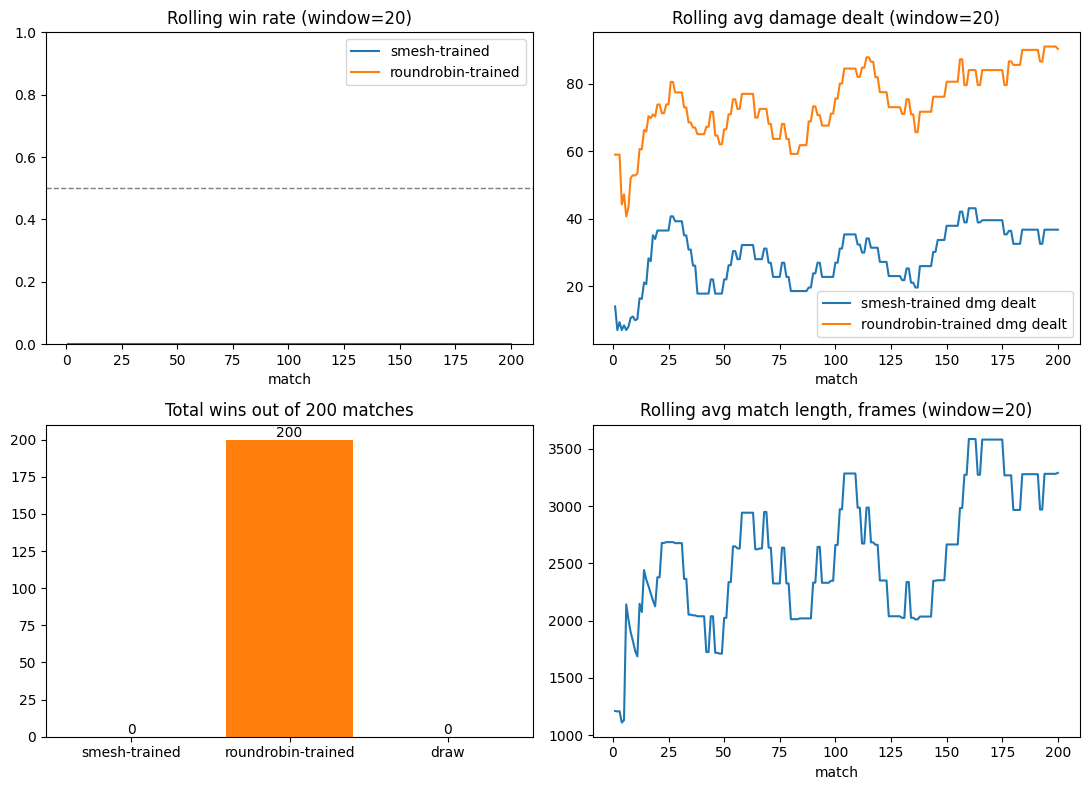

In [9]:
smesh_win_rolling = df["winner"].eq("smesh-trained").rolling(20, min_periods=1).mean()
rr_win_rolling = df["winner"].eq("roundrobin-trained").rolling(20, min_periods=1).mean()
dmg_dealt_rolling = df["smesh_damage_dealt"].rolling(20, min_periods=1).mean()
dmg_taken_rolling = df["smesh_damage_taken"].rolling(20, min_periods=1).mean()
frames_rolling = df["frames"].rolling(20, min_periods=1).mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].plot(df["match"], smesh_win_rolling, label="smesh-trained")
axes[0, 0].plot(df["match"], rr_win_rolling, label="roundrobin-trained")
axes[0, 0].axhline(0.5, color="grey", linestyle="--", linewidth=1)
axes[0, 0].set_ylim(0, 1)
axes[0, 0].set_title("Rolling win rate (window=20)")
axes[0, 0].set_xlabel("match")
axes[0, 0].legend()

axes[0, 1].plot(df["match"], dmg_dealt_rolling, label="smesh-trained dmg dealt")
axes[0, 1].plot(df["match"], dmg_taken_rolling, label="roundrobin-trained dmg dealt")
axes[0, 1].set_title("Rolling avg damage dealt (window=20)")
axes[0, 1].set_xlabel("match")
axes[0, 1].legend()

counts = df["winner"].value_counts().reindex(["smesh-trained", "roundrobin-trained", "draw"], fill_value=0)
axes[1, 0].bar(counts.index, counts.values, color=["tab:blue", "tab:orange", "tab:grey"])
axes[1, 0].set_title(f"Total wins out of {len(df)} matches")
for i, v in enumerate(counts.values):
    axes[1, 0].text(i, v, str(v), ha="center", va="bottom")

axes[1, 1].plot(df["match"], frames_rolling)
axes[1, 1].set_title("Rolling avg match length, frames (window=20)")
axes[1, 1].set_xlabel("match")

fig.tight_layout()


In [10]:
n = len(df)
smesh_wins = (df["winner"] == "smesh-trained").sum()
rr_wins = (df["winner"] == "roundrobin-trained").sum()
draws = (df["winner"] == "draw").sum()

print(f"Matches:                 {n}")
print(f"smesh-trained wins:      {smesh_wins:4d} ({smesh_wins / n:.1%})")
print(f"roundrobin-trained wins: {rr_wins:4d} ({rr_wins / n:.1%})")
print(f"draws:                   {draws:4d} ({draws / n:.1%})")
print()
print(f"avg damage dealt  - smesh-trained: {df['smesh_damage_dealt'].mean():6.2f}  roundrobin-trained: {df['smesh_damage_taken'].mean():6.2f}")
print(f"avg damage taken  - smesh-trained: {df['smesh_damage_taken'].mean():6.2f}  roundrobin-trained: {df['smesh_damage_dealt'].mean():6.2f}")
print(f"avg stocks left   - smesh-trained: {df['smesh_stocks_left'].mean():.2f}  roundrobin-trained: {df['rr_stocks_left'].mean():.2f}")
print(f"avg match length: {df['frames'].mean():.1f} frames ({df['frames'].mean() / 30:.1f}s)")
print()
print("win rate by starting position (checks for positional bias):")
print(df.groupby("smesh_position")["winner"].value_counts(normalize=True).unstack(fill_value=0))


Matches:                 200
smesh-trained wins:         0 (0.0%)
roundrobin-trained wins:  200 (100.0%)
draws:                      0 (0.0%)

avg damage dealt  - smesh-trained:  29.75  roundrobin-trained:  75.99
avg damage taken  - smesh-trained:  75.99  roundrobin-trained:  29.75
avg stocks left   - smesh-trained: 0.24  roundrobin-trained: 1.29
avg match length: 2625.2 frames (87.5s)

win rate by starting position (checks for positional bias):
winner          roundrobin-trained
smesh_position                    
P0                             1.0
P1                             1.0
